## Gaming Addiction Analysis
Dataset: https://www.kaggle.com/datasets/dreamtensor/gaming-addiction-and-mental-health-analysis

In [680]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split, 
    cross_validate,
    KFold,
    GridSearchCV
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)
from sklearn.metrics import(
    mean_absolute_error, 
    mean_squared_error, 
    r2_score
)

In [681]:
path = "/Users/kendrick/practice/gaming_addiction.csv"
df = pd.read_csv(path)

In [682]:
pd.set_option("display.max_columns", None)
df.head(10)

,user_id,age,gender,country,occupation,income_level,years_gaming,preferred_genre,platform,device_type,rank_tier,daily_playtime_hours,weekly_play_sessions,late_night_sessions_hours,weekend_playtime_hours,consecutive_hours_max,multiplayer_ratio,toxic_chat_reports,rage_quit_frequency,in_game_purchases,monthly_spending_usd,lootbox_openings,subscription_status,stress_score,loneliness_score,dopamine_dependency_index,self_control_score,impulsiveness_score,anxiety_level,depression_indicator,emotional_stability,sleep_hours,exercise_frequency_per_week,caffeine_intake_cups_day,social_interaction_hours,relationship_status,gpa_or_performance_score,missed_deadlines,productivity_drop_percent,absenteeism_days,internet_speed_mbps,screen_time_total_hours,behavioral_cluster,addiction_score,addiction_binary,addiction_severity,burnout_probability,mental_health_risk_score,churn_probability
0,USR000001,21,Male,India,Employed,Middle,9,Sandbox,PC,Laptop,Gold,3.5,4,1.0,4.9,6.5,0.67,0,0,0,38.67,10,NaN,8.2,8.8,2.7,7.0,5.1,9.9,8.5,3.7,6.3,2,0,2.7,In a relationship,4.00,4,0.0,7,39.9,5.4,Casual Enjoyer,27.61,0,Mild,1.00,0.920,1.000
1,USR000002,25,Male,India,Employed,Lower-Middle,13,RPG,Mobile,Mixed,Bronze,10.9,14,3.2,14.7,15.9,0.44,2,0,7,47.35,18,Premium,7.8,5.6,8.2,6.5,3.5,6.2,4.1,3.0,6.1,0,2,3.5,In a relationship,4.00,4,16.7,6,71.5,13.4,Streamer/Creator,55.51,1,Moderate,1.00,0.515,0.813
2,USR000003,26,Male,Brazil,Employed,Middle,14,RPG,PC+Mobile,High-end PC,Master,8.6,7,2.4,11.6,13.1,0.32,0,1,3,37.80,4,Ultimate,8.4,4.1,5.0,4.2,6.1,7.7,6.7,3.3,6.1,1,3,2.0,Prefer not to say,4.00,6,8.5,7,119.4,12.3,Streamer/Creator,45.85,0,Moderate,1.00,0.720,0.947
3,USR000004,22,Male,South Korea,Employed,Upper-Middle,10,Strategy,PC+Mobile,Mobile,Bronze,5.9,5,1.1,13.6,8.2,0.23,7,7,9,74.51,15,NaN,6.0,4.5,6.0,5.8,3.6,5.9,4.5,6.5,6.7,4,5,0.6,Married,4.00,3,8.7,8,136.5,6.9,Toxic Competitor,39.87,0,Mild,1.00,0.520,0.660
4,USR000005,17,Female,India,Student,Middle,5,Strategy,PC,Laptop,Bronze,7.4,8,3.2,6.3,14.2,0.57,4,2,5,25.32,0,Premium,8.0,4.2,6.2,6.5,5.0,8.4,3.3,5.5,7.6,1,0,1.2,Single,2.60,3,21.9,6,78.8,9.3,Competitive Grinder,46.97,0,Moderate,1.00,0.585,0.867
5,USR000006,13,Male,USA,Freelancer,Middle,1,Horror,PC,Mobile,Silver,1.4,1,0.0,1.7,3.5,0.35,0,0,9,18.71,0,NaN,1.0,7.2,2.2,7.0,4.2,3.0,5.0,10.0,7.2,3,1,3.1,In a relationship,4.00,0,0.0,3,93.8,3.7,Casual Enjoyer,17.26,0,NaN,0.32,0.400,0.150
6,USR000007,27,Male,UK,Unemployed,Lower-Middle,15,RPG,Console,Console,Silver,8.0,10,2.9,10.6,12.3,0.49,17,7,7,0.00,9,Premium,7.6,5.5,4.6,8.4,4.3,5.8,5.2,3.9,8.0,1,3,0.5,In a relationship,4.00,2,30.2,12,5.0,10.0,Toxic Competitor,34.82,0,Mild,1.00,0.550,0.879
7,USR000008,18,Non-binary,Canada,Student,Middle,6,MOBA,PC,Mixed,Bronze,2.2,3,0.2,3.2,5.1,0.51,1,0,3,14.17,2,Premium,4.6,6.9,1.4,4.7,3.9,4.7,5.1,8.5,7.3,0,0,3.6,Single,3.35,2,0.0,5,97.1,4.7,Casual Enjoyer,22.66,0,Mild,1.00,0.490,0.825
8,USR000009,16,Female,USA,Student,High,1,Sports,Mobile,Mixed,Gold,8.3,12,1.7,11.5,11.9,0.67,6,6,13,95.67,22,Basic,8.1,3.2,6.1,10.0,2.6,4.8,3.2,3.8,7.5,0,3,4.7,In a relationship,2.72,3,35.2,5,81.9,11.0,Toxic Competitor,35.08,0,Mild,1.00,0.400,0.928
9,USR000010,30,Female,Brazil,Freelancer,Middle,18,Strategy,Console,Mid-range PC,Gold,6.9,8,2.4,6.1,12.7,0.53,9,7,0,55.90,14,Premium,4.9,1.0,2.9,3.4,6.4,4.8,1.0,7.2,5.4,2,1,4.8,In a relationship,4.00,2,24.8,3,22.2,7.5,Competitive Grinder,46.24,0,Moderate,1.00,0.290,0.756


In [683]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 49 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   user_id                      250 non-null    str    
 1   age                          250 non-null    int64  
 2   gender                       250 non-null    str    
 3   country                      250 non-null    str    
 4   occupation                   250 non-null    str    
 5   income_level                 250 non-null    str    
 6   years_gaming                 250 non-null    int64  
 7   preferred_genre              250 non-null    str    
 8   platform                     250 non-null    str    
 9   device_type                  250 non-null    str    
 10  rank_tier                    250 non-null    str    
 11  daily_playtime_hours         250 non-null    float64
 12  weekly_play_sessions         250 non-null    int64  
 13  late_night_sessions_hours    25

## Numeric Summary

In [684]:
numeric_summary = df.describe().T
numeric_summary["missing"] = df.isnull().sum()
display(numeric_summary)

,count,mean,std,min,25%,50%,75%,max,missing
age,250.0,22.160000,5.455037,13.00,18.00000,22.000,27.000,40.00,0
years_gaming,250.0,9.668000,5.460866,1.00,6.00000,9.000,14.750,25.00,0
daily_playtime_hours,250.0,6.153200,2.656902,0.50,4.22500,6.450,8.175,11.90,0
weekly_play_sessions,250.0,7.056000,3.517721,1.00,4.00000,7.000,10.000,15.00,0
late_night_sessions_hours,250.0,2.102400,1.200700,0.00,1.12500,2.100,3.000,5.20,0
weekend_playtime_hours,250.0,8.368400,4.085876,0.50,5.60000,8.150,10.850,20.00,0
consecutive_hours_max,250.0,9.714800,4.828877,1.00,5.52500,10.100,13.175,20.60,0
multiplayer_ratio,250.0,0.462240,0.227391,0.00,0.30000,0.450,0.630,1.00,0
toxic_chat_reports,250.0,2.948000,5.451621,0.00,0.00000,1.000,2.000,32.00,0
rage_quit_frequency,250.0,1.896000,2.353581,0.00,0.00000,1.000,3.000,10.00,0


## Checking for duplicates

In [685]:
print("Number of duplicated rows:", df["user_id"].duplicated().sum())

Number of duplicated rows: 0


## Identifying missing values

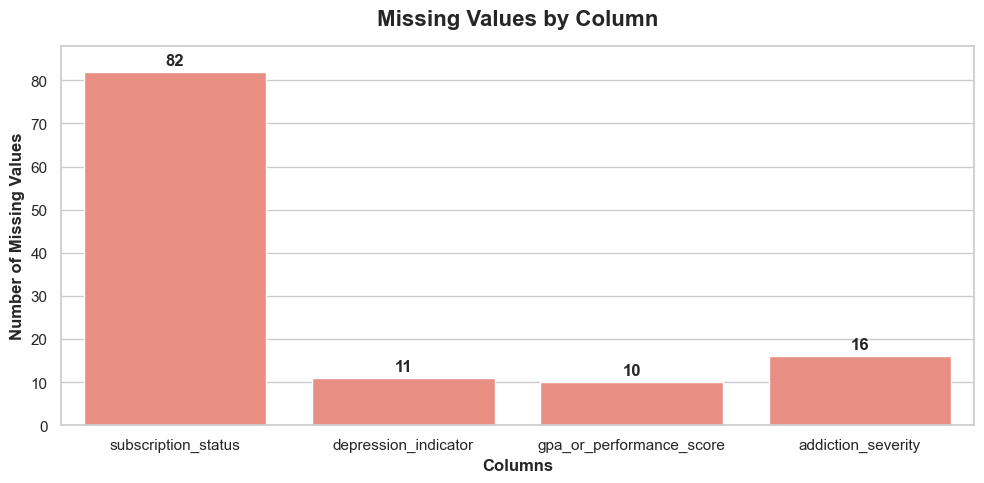

In [686]:
missing_cols = df.isnull().sum()[df.isnull().sum()>0]
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")
ax = sns.barplot(x=missing_cols.index, y=missing_cols.values, color="salmon")
ax.bar_label(ax.containers[0], fmt="%d", padding=3, label_type="edge", fontsize=12, fontweight="bold")
plt.title("Missing Values by Column", fontsize=16, fontweight="bold", pad=15)
plt.ylim(0,88)
plt.xlabel("Columns", fontsize=12, fontweight="bold")
plt.ylabel("Number of Missing Values", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## Subscription Status Distribution

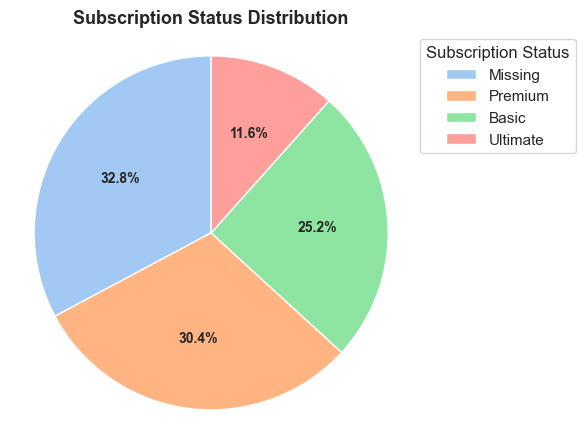

In [687]:
subscription_status = (
    df["subscription_status"]
    .fillna("Missing")
    .value_counts(normalize=True)
)

fig, ax = plt.subplots(figsize=(6, 6))
sns.set_theme(style="whitegrid")

wedges, texts, autotexts = ax.pie(
    subscription_status,
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("pastel"),
    radius=1.1
)

plt.setp(
    autotexts,
    fontsize=10,
    fontweight="bold"
)

ax.set_title(
    "Subscription Status Distribution",
    fontsize=13,
    fontweight="bold",
)

ax.legend(
    subscription_status.index,
    title="Subscription Status",
    loc="upper left",
    frameon=True,
    bbox_to_anchor=(1, 0, 0.5, 1)
)

plt.tight_layout()
plt.show()

In [688]:
# 32.8% is missing while 67.2% is not missing.

## Addiction Severity Distribution

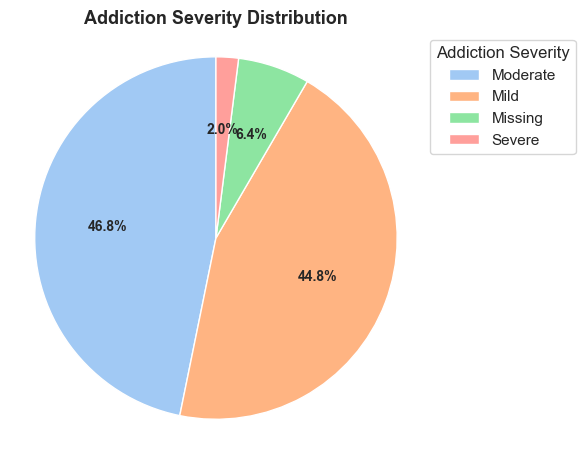

In [689]:
addiction_severity = (
    df["addiction_severity"]
    .fillna("Missing")
    .value_counts(normalize=True)
)

fig, ax = plt.subplots(figsize=(6, 6))
sns.set_theme(style="whitegrid")

wedges, texts, autotexts = ax.pie(
    addiction_severity, 
    autopct="%1.1f%%", 
    startangle=90,
    colors=sns.color_palette("pastel"),
    radius=1.1
)

plt.setp(
    autotexts, 
    size=10, 
    weight="bold"
)

ax.set_title(
    "Addiction Severity Distribution", 
    fontsize=13, 
    fontweight="bold"
)

plt.legend(
    addiction_severity.index, 
    title="Addiction Severity", 
    loc="upper left", 
    frameon=True, 
    bbox_to_anchor=(1, 0, 0.5, 1)
)

plt.tight_layout()
plt.show()

In [690]:
# 6.4% is missing while 93.6% is not missing.

## Check correlation between columns

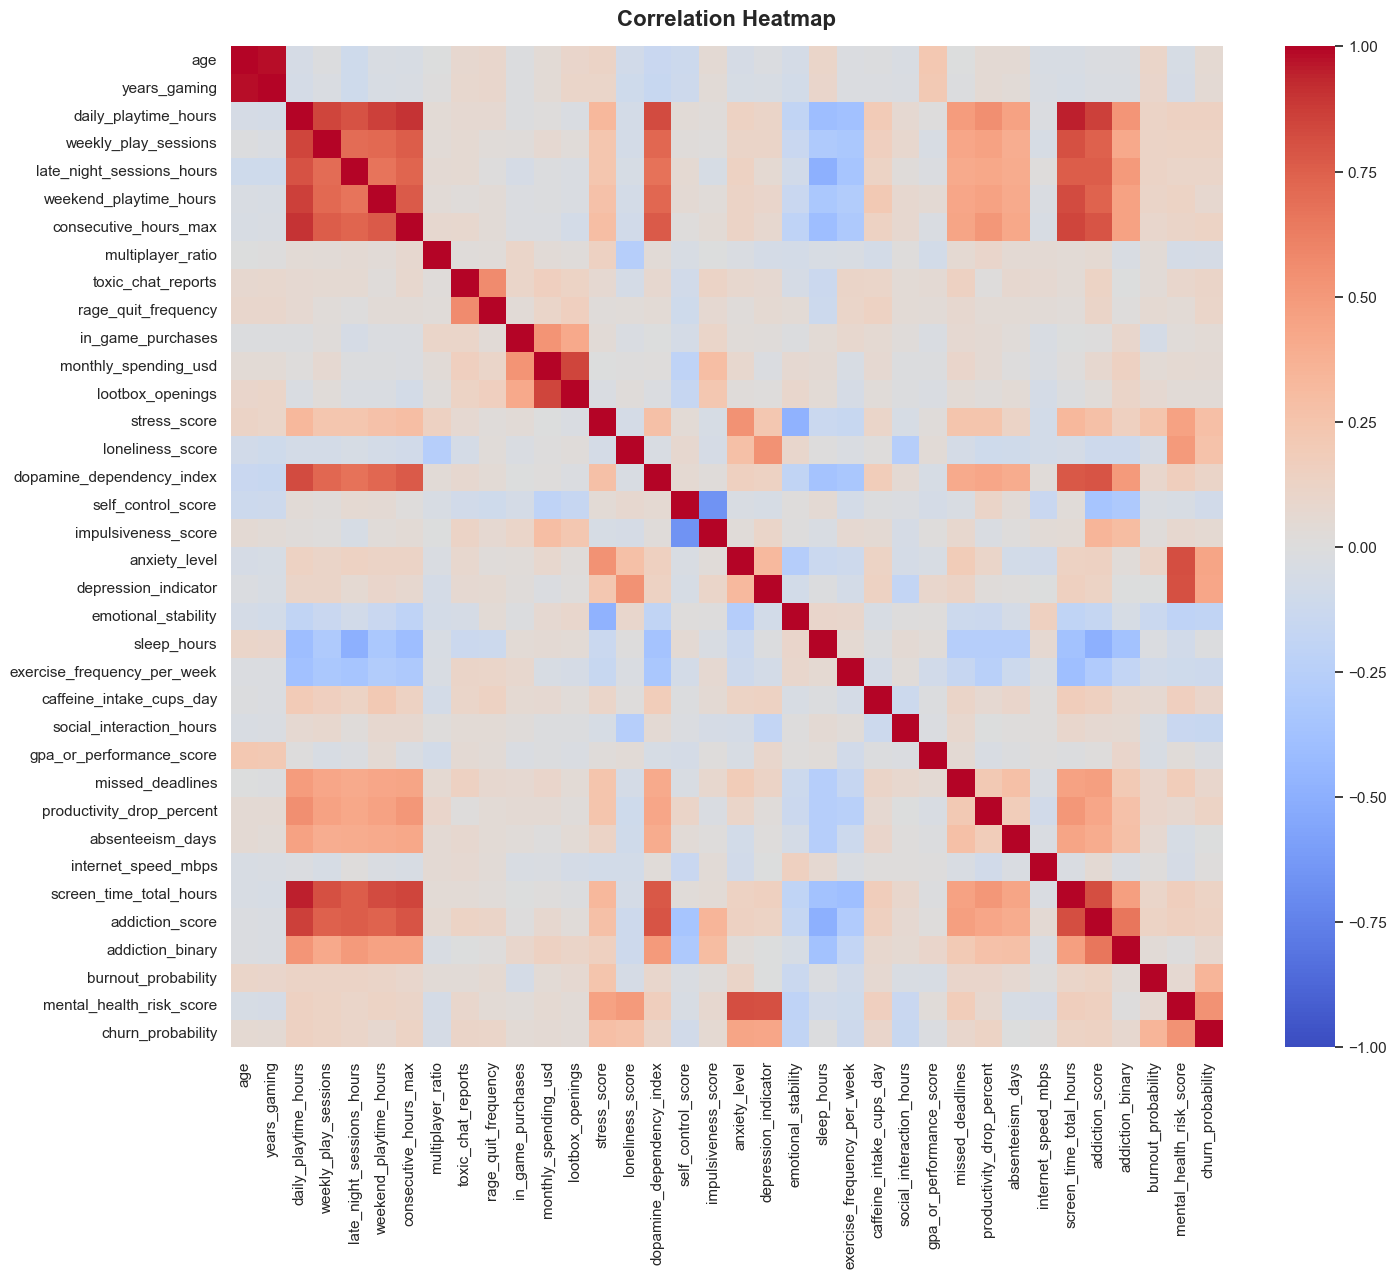

In [691]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(16,13))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)
plt.title("Correlation Heatmap", fontsize=16, fontweight="bold", pad=15)
plt.show()

## Filling missing values

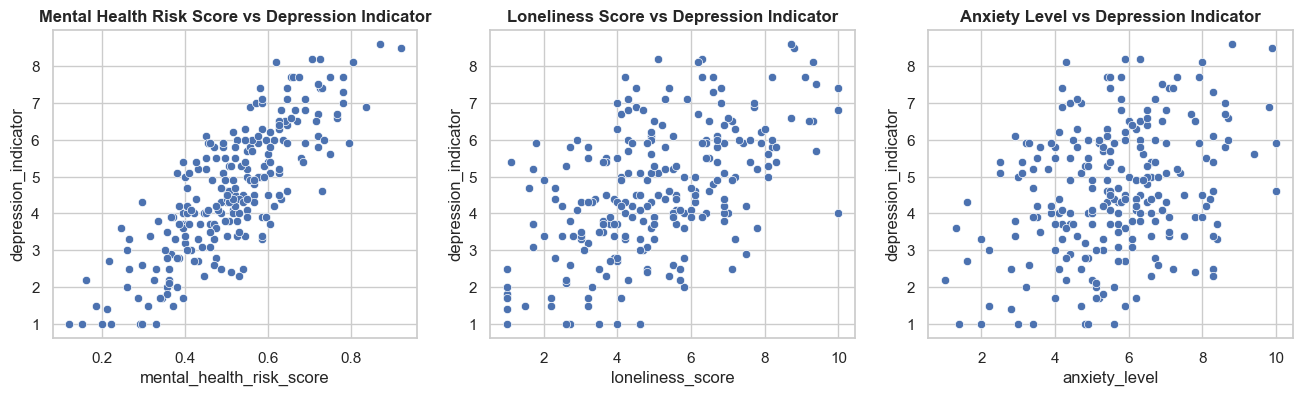

In [692]:
# Based on the correlation heatmap: 
# No strong correlations between gpa_or_performance_score and others.
# Very strong positive correlation between depression_indicator and mental_health_indicator. Strong positive correlationbetween depression_indicator and loneliness_score/anxiety_level

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.scatterplot(
    data=df,
    x="mental_health_risk_score",
    y="depression_indicator",
    ax=axes[0]
)

axes[0].set_title("Mental Health Risk Score vs Depression Indicator", fontsize=12, fontweight="bold")

sns.scatterplot(
    data=df,
    x="loneliness_score",
    y="depression_indicator",
    ax=axes[1]
)

axes[1].set_title("Loneliness Score vs Depression Indicator", fontsize=12, fontweight="bold")

sns.scatterplot(
    data=df,
    x="anxiety_level",
    y="depression_indicator",
    ax=axes[2]
)

axes[2].set_title("Anxiety Level vs Depression Indicator", fontsize=12, fontweight="bold")

plt.show()

In [693]:
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score

target = "depression_indicator"
base_feature = "mental_health_risk_score"

candidate_features = [
    "anxiety_level",
    "loneliness_score",
    "stress_score",
    "emotional_stability"
]

# Keep rows where depression is known
known_df = df[df[target].notna()].copy()

# Cross-validation settings
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = []

for feature in candidate_features:

    # Select the two predictors and target
    test_data = known_df[
        [base_feature, feature, target]
    ].dropna()

    X = test_data[[base_feature, feature]]
    y = test_data[target]

    model = LinearRegression()

    # Test the model on different sections of the data
    r2_scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="r2"
    )

    mae_scores = -cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="neg_mean_absolute_error"
    )

    # Fit on all known rows only to inspect the equation
    model.fit(X, y)

    results.append({
        "candidate_feature": feature,
        "mean_r2": r2_scores.mean(),
        "mean_mae": round(mae_scores.mean(), 2),
        "intercept": round(model.intercept_, 2),
        "mental_health_coefficient": model.coef_[0],
        "candidate_coefficient": model.coef_[1]
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by=["mean_r2", "mean_mae"],
    ascending=[False, True]
)

display(results_df)

,candidate_feature,mean_r2,mean_mae,intercept,mental_health_coefficient,candidate_coefficient
0,anxiety_level,1.000000,0.00,-0.00,20.000000,-1.000000
2,stress_score,0.652132,0.78,0.38,11.023739,-0.203572
1,loneliness_score,0.638882,0.79,-0.64,8.790353,0.152808
3,emotional_stability,0.633669,0.81,-1.31,10.172395,0.113505


In [694]:
# depression_indicator = (20 * mental_health_risk_score) + (-1 * anxiety_level)

In [695]:
df["depression_indicator_new"] = 20 * df["mental_health_risk_score"] + -1 * df["anxiety_level"]

df[["mental_health_risk_score", "anxiety_level", "depression_indicator", "depression_indicator_new"]].head(10)

,mental_health_risk_score,anxiety_level,depression_indicator,depression_indicator_new
0,0.920,9.9,8.5,8.5
1,0.515,6.2,4.1,4.1
2,0.720,7.7,6.7,6.7
3,0.520,5.9,4.5,4.5
4,0.585,8.4,3.3,3.3
5,0.400,3.0,5.0,5.0
6,0.550,5.8,5.2,5.2
7,0.490,4.7,5.1,5.1
8,0.400,4.8,3.2,3.2
9,0.290,4.8,1.0,1.0


In [696]:
df.drop(columns=["depression_indicator"], inplace=True)

df.head(10)

,user_id,age,gender,country,occupation,income_level,years_gaming,preferred_genre,platform,device_type,rank_tier,daily_playtime_hours,weekly_play_sessions,late_night_sessions_hours,weekend_playtime_hours,consecutive_hours_max,multiplayer_ratio,toxic_chat_reports,rage_quit_frequency,in_game_purchases,monthly_spending_usd,lootbox_openings,subscription_status,stress_score,loneliness_score,dopamine_dependency_index,self_control_score,impulsiveness_score,anxiety_level,emotional_stability,sleep_hours,exercise_frequency_per_week,caffeine_intake_cups_day,social_interaction_hours,relationship_status,gpa_or_performance_score,missed_deadlines,productivity_drop_percent,absenteeism_days,internet_speed_mbps,screen_time_total_hours,behavioral_cluster,addiction_score,addiction_binary,addiction_severity,burnout_probability,mental_health_risk_score,churn_probability,depression_indicator_new
0,USR000001,21,Male,India,Employed,Middle,9,Sandbox,PC,Laptop,Gold,3.5,4,1.0,4.9,6.5,0.67,0,0,0,38.67,10,NaN,8.2,8.8,2.7,7.0,5.1,9.9,3.7,6.3,2,0,2.7,In a relationship,4.00,4,0.0,7,39.9,5.4,Casual Enjoyer,27.61,0,Mild,1.00,0.920,1.000,8.5
1,USR000002,25,Male,India,Employed,Lower-Middle,13,RPG,Mobile,Mixed,Bronze,10.9,14,3.2,14.7,15.9,0.44,2,0,7,47.35,18,Premium,7.8,5.6,8.2,6.5,3.5,6.2,3.0,6.1,0,2,3.5,In a relationship,4.00,4,16.7,6,71.5,13.4,Streamer/Creator,55.51,1,Moderate,1.00,0.515,0.813,4.1
2,USR000003,26,Male,Brazil,Employed,Middle,14,RPG,PC+Mobile,High-end PC,Master,8.6,7,2.4,11.6,13.1,0.32,0,1,3,37.80,4,Ultimate,8.4,4.1,5.0,4.2,6.1,7.7,3.3,6.1,1,3,2.0,Prefer not to say,4.00,6,8.5,7,119.4,12.3,Streamer/Creator,45.85,0,Moderate,1.00,0.720,0.947,6.7
3,USR000004,22,Male,South Korea,Employed,Upper-Middle,10,Strategy,PC+Mobile,Mobile,Bronze,5.9,5,1.1,13.6,8.2,0.23,7,7,9,74.51,15,NaN,6.0,4.5,6.0,5.8,3.6,5.9,6.5,6.7,4,5,0.6,Married,4.00,3,8.7,8,136.5,6.9,Toxic Competitor,39.87,0,Mild,1.00,0.520,0.660,4.5
4,USR000005,17,Female,India,Student,Middle,5,Strategy,PC,Laptop,Bronze,7.4,8,3.2,6.3,14.2,0.57,4,2,5,25.32,0,Premium,8.0,4.2,6.2,6.5,5.0,8.4,5.5,7.6,1,0,1.2,Single,2.60,3,21.9,6,78.8,9.3,Competitive Grinder,46.97,0,Moderate,1.00,0.585,0.867,3.3
5,USR000006,13,Male,USA,Freelancer,Middle,1,Horror,PC,Mobile,Silver,1.4,1,0.0,1.7,3.5,0.35,0,0,9,18.71,0,NaN,1.0,7.2,2.2,7.0,4.2,3.0,10.0,7.2,3,1,3.1,In a relationship,4.00,0,0.0,3,93.8,3.7,Casual Enjoyer,17.26,0,NaN,0.32,0.400,0.150,5.0
6,USR000007,27,Male,UK,Unemployed,Lower-Middle,15,RPG,Console,Console,Silver,8.0,10,2.9,10.6,12.3,0.49,17,7,7,0.00,9,Premium,7.6,5.5,4.6,8.4,4.3,5.8,3.9,8.0,1,3,0.5,In a relationship,4.00,2,30.2,12,5.0,10.0,Toxic Competitor,34.82,0,Mild,1.00,0.550,0.879,5.2
7,USR000008,18,Non-binary,Canada,Student,Middle,6,MOBA,PC,Mixed,Bronze,2.2,3,0.2,3.2,5.1,0.51,1,0,3,14.17,2,Premium,4.6,6.9,1.4,4.7,3.9,4.7,8.5,7.3,0,0,3.6,Single,3.35,2,0.0,5,97.1,4.7,Casual Enjoyer,22.66,0,Mild,1.00,0.490,0.825,5.1
8,USR000009,16,Female,USA,Student,High,1,Sports,Mobile,Mixed,Gold,8.3,12,1.7,11.5,11.9,0.67,6,6,13,95.67,22,Basic,8.1,3.2,6.1,10.0,2.6,4.8,3.8,7.5,0,3,4.7,In a relationship,2.72,3,35.2,5,81.9,11.0,Toxic Competitor,35.08,0,Mild,1.00,0.400,0.928,3.2
9,USR000010,30,Female,Brazil,Freelancer,Middle,18,Strategy,Console,Mid-range PC,Gold,6.9,8,2.4,6.1,12.7,0.53,9,7,0,55.90,14,Premium,4.9,1.0,2.9,3.4,6.4,4.8,7.2,5.4,2,1,4.8,In a relationship,4.00,2,24.8,3,22.2,7.5,Competitive Grinder,46.24,0,Moderate,1.00,0.290,0.756,1.0


In [697]:
df["subscription_status"] = df["subscription_status"].fillna("Free")

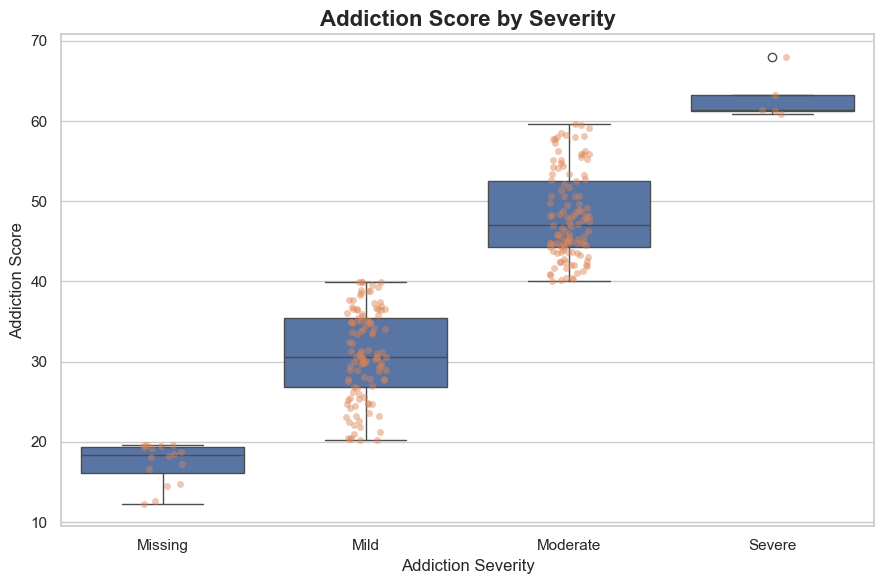

In [698]:
severity_plot = df.copy()

severity_plot["addiction_severity"] = (
    severity_plot["addiction_severity"]
    .fillna("Missing")
)

order = ["Missing", "Mild", "Moderate", "Severe"]

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=severity_plot,
    x="addiction_severity",
    y="addiction_score",
    order=order
)

sns.stripplot(
    data=severity_plot,
    x="addiction_severity",
    y="addiction_score",
    order=order,
    alpha=0.45,
    jitter=True
)

plt.title(
    "Addiction Score by Severity",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Addiction Severity")
plt.ylabel("Addiction Score")
plt.tight_layout()
plt.show()

In [699]:
df["addiction_severity"] = df["addiction_severity"].fillna("None")

In [700]:
df = df.rename(
    columns={
        "depression_indicator_new": "depression_indicator"
    }
)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 49 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   user_id                      250 non-null    str    
 1   age                          250 non-null    int64  
 2   gender                       250 non-null    str    
 3   country                      250 non-null    str    
 4   occupation                   250 non-null    str    
 5   income_level                 250 non-null    str    
 6   years_gaming                 250 non-null    int64  
 7   preferred_genre              250 non-null    str    
 8   platform                     250 non-null    str    
 9   device_type                  250 non-null    str    
 10  rank_tier                    250 non-null    str    
 11  daily_playtime_hours         250 non-null    float64
 12  weekly_play_sessions         250 non-null    int64  
 13  late_night_sessions_hours    25

## Who are the gamers?

Before looking at addiction, let's understand the population we're studying using:
age, gender, country, occupation

- most of them are 19-23 year old
- most of them are male
- most of them are from USA
- most of them are employed

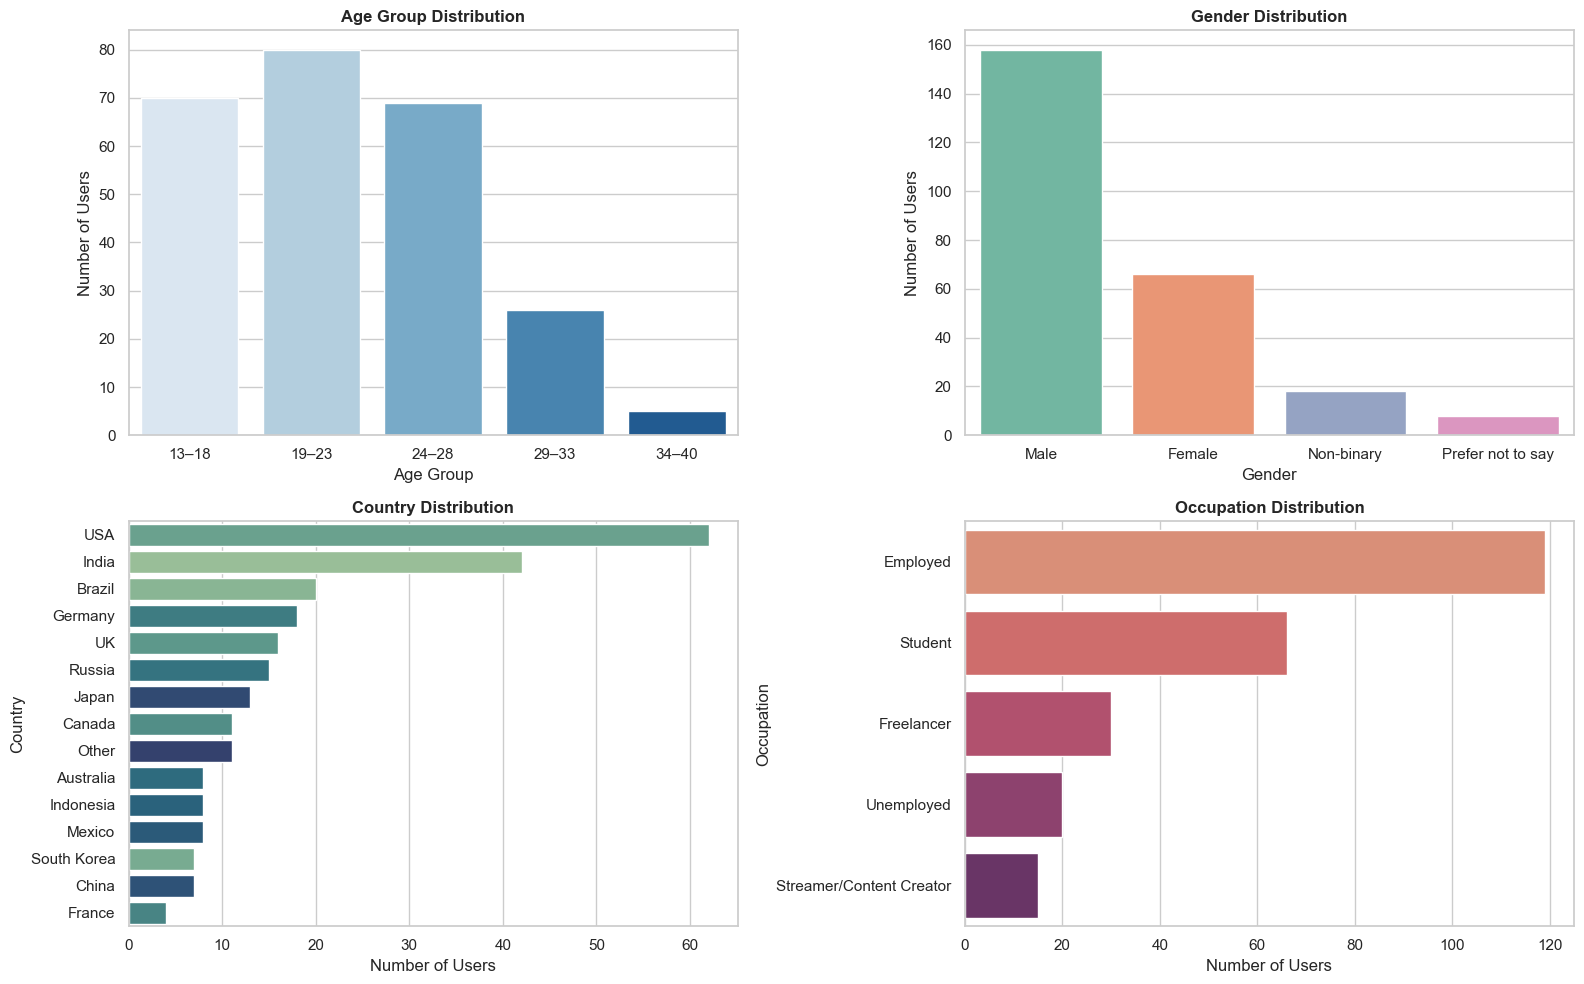

In [701]:
population_columns = [
    "age",
    "gender",
    "country",
    "occupation"
]

df["age_group"] = pd.cut(
    df["age"],
    bins=[12, 18, 23, 28, 33, 40],
    labels=[
        "13–18",
        "19–23",
        "24–28",
        "29–33",
        "34–40"
    ]
)

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Age group
sns.countplot(
    data=df,
    x="age_group",
    hue="age_group",
    palette="Blues",
    dodge=False,
    ax=axes[0, 0]
)

axes[0, 0].set_title(
    "Age Group Distribution",
    fontweight="bold"
)
axes[0, 0].set_xlabel("Age Group")
axes[0, 0].set_ylabel("Number of Users")


# Gender
gender_order = df["gender"].value_counts().index

sns.countplot(
    data=df,
    x="gender",
    hue="gender",
    order=gender_order,
    palette="Set2",
    ax=axes[0, 1]
)

axes[0, 1].set_title(
    "Gender Distribution",
    fontweight="bold"
)
axes[0, 1].set_xlabel("Gender")
axes[0, 1].set_ylabel("Number of Users")


# Country
country_order = df["country"].value_counts().index

sns.countplot(
    data=df,
    y="country",
    hue="country",
    order=country_order,
    palette="crest",
    ax=axes[1, 0]
)

axes[1, 0].set_title(
    "Country Distribution",
    fontweight="bold"
)
axes[1, 0].set_xlabel("Number of Users")
axes[1, 0].set_ylabel("Country")


# Occupation
occupation_order = df["occupation"].value_counts().index

sns.countplot(
    data=df,
    y="occupation",
    hue="occupation",
    order=occupation_order,
    palette="flare",
    ax=axes[1, 1]
)

axes[1, 1].set_title(
    "Occupation Distribution",
    fontweight="bold"
)
axes[1, 1].set_xlabel("Number of Users")
axes[1, 1].set_ylabel("Occupation")

plt.tight_layout()
plt.show()

## Exporatory Data Analysis (EDA)
important columns that have strong relationship with addiction score:

- gaming time and dopamine dependency show noticeable positive relationships with addiction score
- users who spend more time gaming or have higher dopamine dependency generally have higher addiction scores
- sleep hours show a noticeable negative relationship with addiction score
- users who sleep more generally have lower addiction scores

In [702]:
column_overview = pd.DataFrame({
    "data_type": df.dtypes,
    "non_missing": df.notna().sum(),
    "missing": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100,
    "unique_values": df.nunique()
})

column_overview["missing_percent"] = (
    column_overview["missing_percent"]
    .round(2)
)

display(column_overview)

,data_type,non_missing,missing,missing_percent,unique_values
user_id,str,250,0,0.0,250
age,int64,250,0,0.0,25
gender,str,250,0,0.0,4
country,str,250,0,0.0,15
occupation,str,250,0,0.0,5
income_level,str,250,0,0.0,5
years_gaming,int64,250,0,0.0,23
preferred_genre,str,250,0,0.0,10
platform,str,250,0,0.0,5
device_type,str,250,0,0.0,6


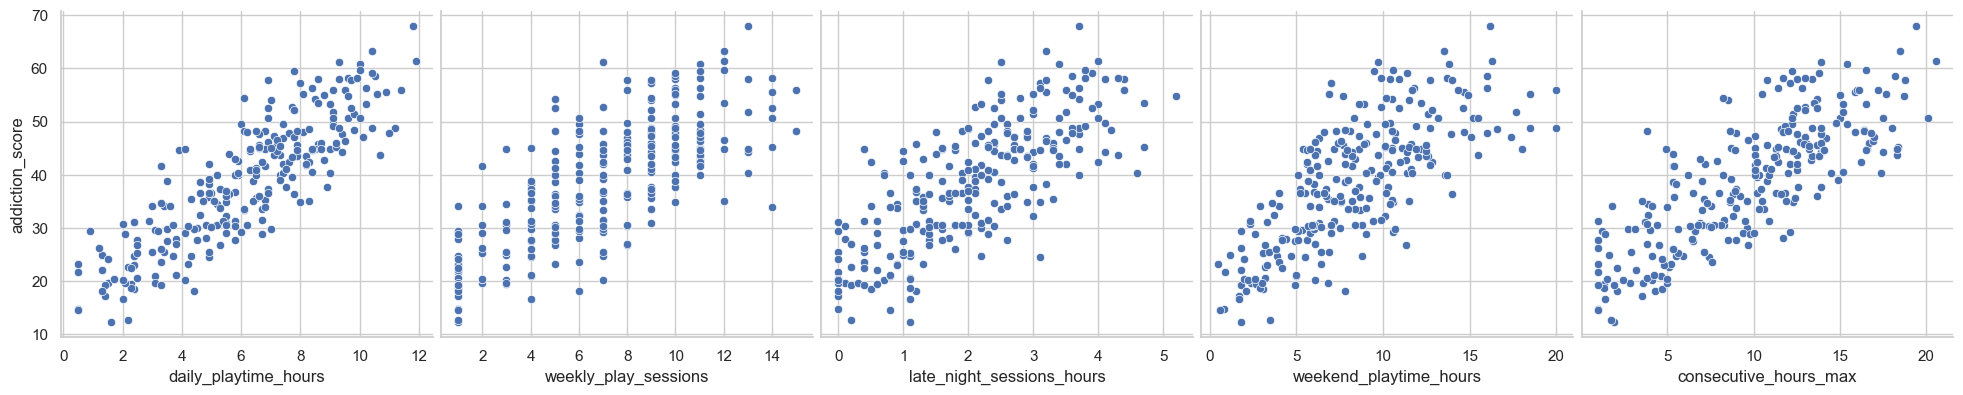

In [703]:
gaming_time = [
    "daily_playtime_hours", 
    "weekly_play_sessions", 
    "late_night_sessions_hours", 
    "weekend_playtime_hours", 
    "consecutive_hours_max"
]

sns.pairplot(
    data=df,
    x_vars=gaming_time,
    y_vars=["addiction_score"],
    kind="scatter",
    height=4
)

plt.show()

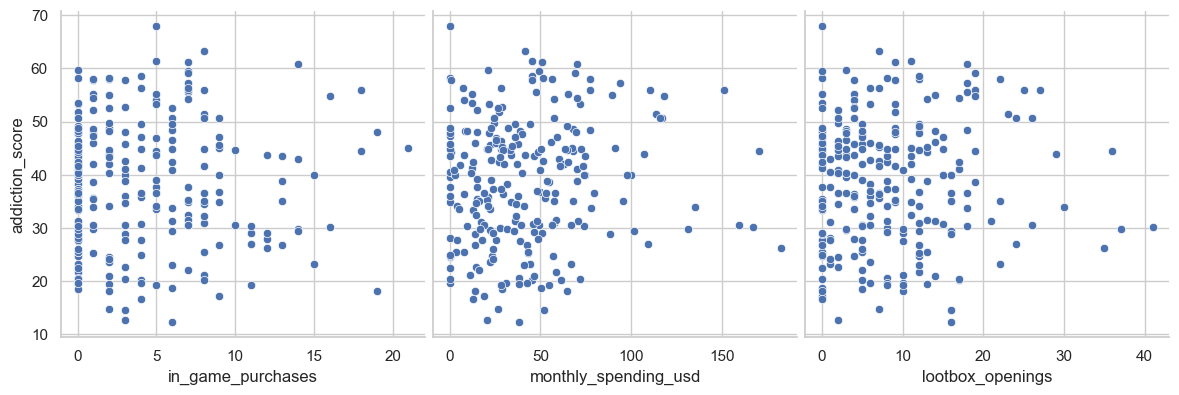

In [704]:
spending = [
    "in_game_purchases", 
    "monthly_spending_usd", 
    "lootbox_openings"
]

sns.pairplot(
    data=df,
    x_vars=spending,
    y_vars=["addiction_score"],
    kind="scatter",
    height=4
)

plt.show()

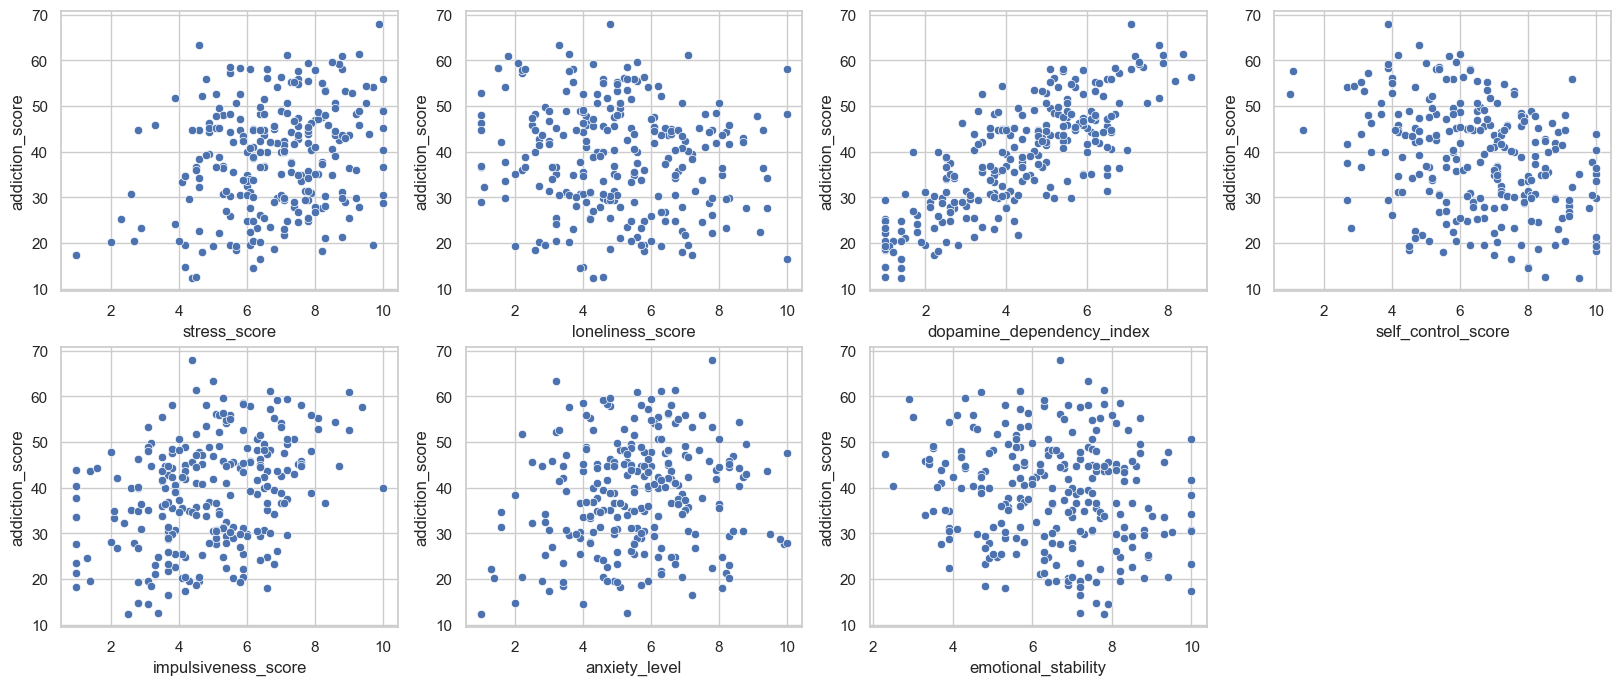

In [705]:
mental_health_columns = [
    "stress_score",
    "loneliness_score",
    "dopamine_dependency_index",
    "self_control_score",
    "impulsiveness_score",
    "anxiety_level",
    "emotional_stability"
]

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(mental_health_columns):
    sns.scatterplot(
        data=df,
        x=col,
        y="addiction_score",
        ax=axes[i]
    )

fig.delaxes(axes[-1])

plt.show()

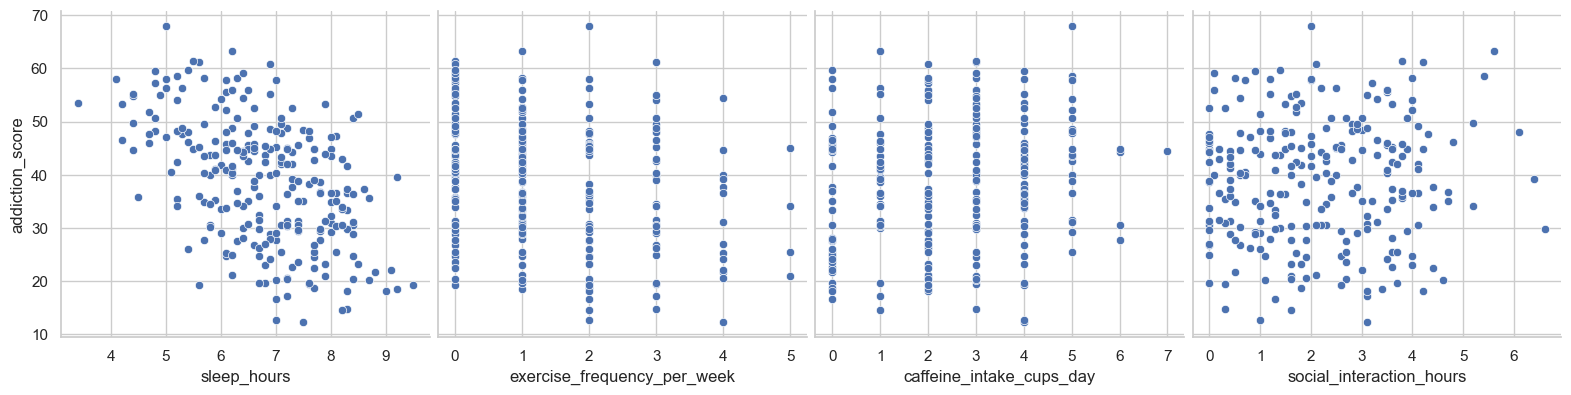

In [706]:
lifestyle = [
    "sleep_hours", 
    "exercise_frequency_per_week", 
    "caffeine_intake_cups_day", 
    "social_interaction_hours"
]

sns.pairplot(
    data=df,
    x_vars=lifestyle,
    y_vars=["addiction_score"],
    kind="scatter",
    height=4
)

plt.show()

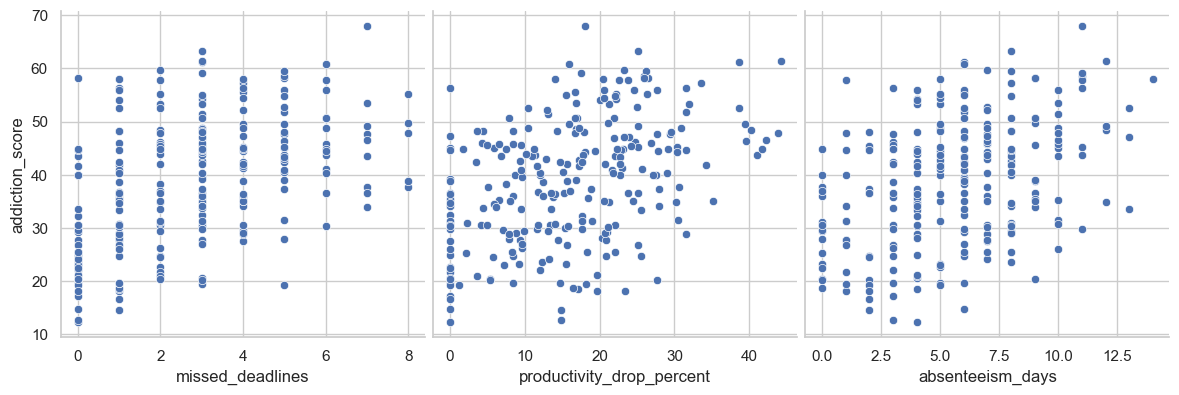

In [707]:
consequence = [
    "missed_deadlines",
    "productivity_drop_percent",
    "absenteeism_days"
]

sns.pairplot(
    data=df,
    x_vars=consequence,
    y_vars=["addiction_score"],
    kind="scatter",
    height=4
)

plt.show()

## Building a predictive model
- addiction_score is a regression type
- addiction_binary is a classification type
- addiction_severity is a multiclass classification type

In [708]:
# Addiction score
target = "addiction_score"

columns_to_drop = [
    "user_id",
    "addiction_score",
    "addiction_binary",
    "addiction_severity",
    "behavioral_cluster",
    "burnout_probability",
    "mental_health_risk_score",
    "churn_probability",
    "depression_indicator"
]

X = df.drop(columns=columns_to_drop)
y = df[target]

numeric_columns = X.select_dtypes(include=["int64", "float64"]).columns
categorical_columns = X.select_dtypes(include=["object", "string", "category"]).columns

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_columns),
    ("categorical", categorical_pipeline, categorical_columns)
])

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=300,
        max_depth=5,
        min_samples_leaf=3,
        random_state=42
    ))
])

## Train test split

In [709]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 200
Testing rows: 50


## Compare Candidate Models with Cross-Validation

In [710]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    ),
    "Ridge Regression": Ridge()
}

comparison_results = []

for model_name, regressor in models.items():

    candidate_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", regressor)
    ])

    scores = cross_validate(
        candidate_pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "MAE": "neg_mean_absolute_error",
            "MSE": "neg_mean_squared_error",
            "R2": "r2"
        }
    )

    comparison_results.append({
        "Model": model_name,
        "Mean MAE": -scores["test_MAE"].mean(),
        "Mean MSE": -scores["test_MSE"].mean(),
        "Mean R2": scores["test_R2"].mean(),
        "R2 Standard Deviation": scores["test_R2"].std()
    })

model_comparison = (
    pd.DataFrame(comparison_results)
    .sort_values("Mean R2", ascending=False)
    .reset_index(drop=True)
)

display(model_comparison.round(3))

,Model,Mean MAE,Mean MSE,Mean R2,R2 Standard Deviation
0,Ridge Regression,2.836,11.913,0.907,0.025
1,Linear Regression,3.116,14.466,0.887,0.029
2,Gradient Boosting,3.219,16.164,0.875,0.025
3,Random Forest,3.555,19.889,0.847,0.017


## Finding the best hyperparameter

In [711]:
ridge_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", Ridge())
])

ridge_parameter_grid = {
    "regressor__alpha": [
        0.001,
        0.01,
        0.1,
        1,
        10,
        20,
        30,
        100
    ]
}

ridge_grid_search = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=ridge_parameter_grid,
    cv=cv,
    scoring="r2",
    n_jobs=-1,
    refit=True
)

ridge_grid_search.fit(X_train, y_train)

print("Best Ridge parameters:")
print(ridge_grid_search.best_params_)

print(
    "Best Ridge CV R2:",
    round(ridge_grid_search.best_score_, 3)
)

Best Ridge parameters:
{'regressor__alpha': 20}
Best Ridge CV R2: 0.925


## Building the best model

In [712]:
best_model = ridge_grid_search.best_estimator_
y_pred = best_model.predict(X_test)

## Model Evaluation

In [713]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

evaluation = pd.DataFrame({
    "Metric": ["MAE", "MSE", "R2"],
    "Score": [mae, mse, r2]
})

display(evaluation)

,Metric,Score
0,MAE,2.705166
1,MSE,10.752349
2,R2,0.933626
